# Ejercicio 5 - Incorporacion de 2024

El descargador recibe los anios como parametro; agregar 2024 no requiere modificar el
flujo. Los archivos de 2026 se conservan y los ya existentes no se descargan de nuevo.

## 5.1 a 5.5. Descarga incremental

In [1]:
import lab_utils
!python scripts/download_data.py --years 2024 2026


=== YELLOW 2024 ===
  2024-01  ya existe, se omite
  2024-02  ya existe, se omite


  2024-03  ya existe, se omite
  2024-04  ya existe, se omite
  2024-05  ya existe, se omite
  2024-06  ya existe, se omite
  2024-07  ya existe, se omite


  2024-08  ya existe, se omite
  2024-09  ya existe, se omite
  2024-10  ya existe, se omite
  2024-11  ya existe, se omite


  2024-12  ya existe, se omite

=== GREEN 2024 ===
  2024-01  ya existe, se omite
  2024-02  ya existe, se omite


  2024-03  ya existe, se omite
  2024-04  ya existe, se omite
  2024-05  ya existe, se omite
  2024-06  ya existe, se omite
  2024-07  ya existe, se omite


...

  2026-03  ya existe, se omite
  2026-04  ya existe, se omite
  2026-05  ya existe, se omite
  2026-06  ya existe, se omite
  2026-07  ya existe, se omite
  2026-08  ya existe, se omite


  2026-09  aun no publicado por la TLC


  2026-10  aun no publicado por la TLC


  2026-11  aun no publicado por la TLC


  2026-12  aun no publicado por la TLC

Tabla de zonas ya existe: data/raw/zones/taxi_zone_lookup.csv

RESUMEN
  descargados   : 0
  ya existian   : 40
  no publicados : 8
      yellow 2026-09, yellow 2026-10, yellow 2026-11, yellow 2026-12, green 2026-09, green 2026-10, green 2026-11, green 2026-12
  fallidos      : 0


## 5.5 y 5.6. Validacion con DuckDB

Consultas de `sql/03_validacion_incremental.sql` (5.8).

In [2]:
from lab_utils import conectar, ejecutar
import matplotlib.pyplot as plt

con = conectar()

In [3]:
ejecutar(con, "03_validacion_incremental.sql", "01_archivos_por_anio_tipo")

**Cobertura de archivos incorporados** (`03_validacion_incremental.sql` - `01_archivos_por_anio_tipo`)

- **Objetivo:** Verificar cuantos meses locales existen para cada anio y tipo de taxi.
- **Decision:** Para 2024 se esperan doce meses por tipo; para 2026 solo los meses ya publicados por TLC.

```sql
WITH archivos AS (
    SELECT file,
           regexp_extract(file, '(yellow|green)', 1) AS tipo_taxi,
           CAST(regexp_extract(file, 'tripdata_(\d{4})-', 1) AS INTEGER) AS anio,
           CAST(regexp_extract(file, '-(\d{2})\.parquet$', 1) AS INTEGER) AS mes
    FROM glob('data/raw/*/*/*.parquet')
)
SELECT anio, tipo_taxi, count(*) AS archivos, min(mes) AS primer_mes,
       max(mes) AS ultimo_mes, count(DISTINCT mes) AS meses_distintos
FROM archivos
WHERE anio IN (2024, 2026)
GROUP BY anio, tipo_taxi ORDER BY anio, tipo_taxi;
```

,anio,tipo_taxi,archivos,primer_mes,ultimo_mes,meses_distintos
0,2024,green,12,1,12,12
1,2024,yellow,12,1,12,12
2,2026,green,8,1,8,8
3,2026,yellow,8,1,8,8


In [4]:
ejecutar(con, "03_validacion_incremental.sql", "02_registros_conjuntos")

**Registros consultados conjuntamente** (`03_validacion_incremental.sql` - `02_registros_conjuntos`)

- **Objetivo:** Comprobar con DuckDB que 2024 y 2026 se leen en una sola consulta.
- **Decision:** Extraer el anio desde el nombre del archivo evita confiar en fechas atipicas dentro de un archivo mensual.

```sql
WITH viajes AS (
    SELECT CAST(regexp_extract(filename, 'tripdata_(\d{4})-', 1) AS INTEGER) AS anio,
           CASE WHEN filename LIKE '%yellow%' THEN 'yellow' ELSE 'green' END AS tipo_taxi
    FROM read_parquet('data/raw/*/*/*.parquet', filename = true, union_by_name = true)
)
SELECT anio, tipo_taxi, count(*) AS registros
FROM viajes WHERE anio IN (2024, 2026)
GROUP BY anio, tipo_taxi
UNION ALL
SELECT anio, 'total', count(*) FROM viajes WHERE anio IN (2024, 2026) GROUP BY anio
ORDER BY anio, tipo_taxi;
```

,anio,tipo_taxi,registros
0,2024,green,660218
1,2024,total,41829938
2,2024,yellow,41169720
3,2026,green,337114
4,2026,total,30040469
5,2026,yellow,29703355


**Consulta analitica sobre ambos anios** (`03_validacion_incremental.sql` - `03_comparacion_anual`)

- **Objetivo:** Demostrar que las metricas normalizadas funcionan al ampliar el conjunto de archivos.
- **Decision:** Mantener union_by_name y normalizar las fechas con coalesce permite tolerar las diferencias de esquema entre servicios y anios.

```sql
WITH viajes AS (
    SELECT CAST(regexp_extract(filename, 'tripdata_(\d{4})-', 1) AS INTEGER) AS anio,
           CASE WHEN filename LIKE '%yellow%' THEN 'yellow' ELSE 'green' END AS tipo_taxi,
           coalesce(tpep_pickup_datetime, lpep_pickup_datetime) AS pickup_datetime,
           trip_distance, total_amount
    FROM read_parquet('data/raw/*/*/*.parquet', filename = true, union_by_name = true)
)
SELECT anio, tipo_taxi, count(*) AS viajes,
       round(avg(trip_distance) FILTER (WHERE trip_distance > 0), 2) AS distancia_media,
       round(avg(total_amount) FILTER (WHERE total_amount >= 0), 2) AS monto_medio
FROM viajes
WHERE anio IN (2024, 2026)
  AND year(pickup_datetime) = anio
GROUP BY anio, tipo_taxi ORDER BY anio, tipo_taxi;
```

,anio,tipo_taxi,viajes,distancia_media,monto_medio
0,2024,green,660198,17.96,24.39
1,2024,yellow,41169664,5.07,28.67
2,2026,green,337100,13.85,25.61
3,2026,yellow,29703338,5.74,30.40


<Axes: title={'center': 'Monto medio por viaje (USD)'}, xlabel='anio'>

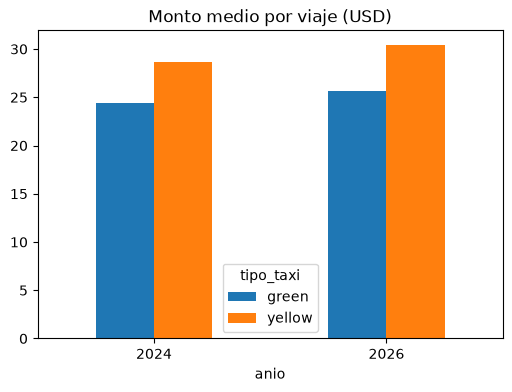

In [5]:
df = ejecutar(con, "03_validacion_incremental.sql", "03_comparacion_anual")
display(df)
df.pivot(index="anio", columns="tipo_taxi", values="monto_medio").plot.bar(
    figsize=(6, 4), title="Monto medio por viaje (USD)", rot=0)

## 5.7. Necesitan cambiar las consultas anteriores?

Las preguntas del Ejercicio 4 siguen siendo validas. Para analizar ambos anios basta con
reemplazar el patron `data/raw/<tipo>/2026/*.parquet` por `data/raw/<tipo>/*/*.parquet`,
obtener `anio` desde `filename` y cambiar el filtro fijo de 2026 por una agrupacion
anual. Las formulas y la normalizacion entre `tpep_*` y `lpep_*` no cambian.

## 5.9. Por que el diseno admite nuevos archivos

- El descargador construye rutas particionadas `data/raw/<tipo>/<anio>/` a partir de
  una lista de anios y valida cada archivo antes de omitirlo.
- Las consultas usan patrones (`*`) en lugar de listas de archivos, por lo que un mes o
  anio nuevo entra automaticamente.
- `union_by_name` tolera diferencias de esquema entre servicios y anios.